# Store Sales Forecasting - 04 Vanilla RNN, LSTM and GRU

This notebook adapts **Recurrent Torch.ipynb** to the store-sales project. It uses the reference's sliding-window idea, PyTorch recurrent layers, final hidden state, DataLoaders, and regression training loop.

The experiment compares **Vanilla RNN**, **LSTM**, and **GRU** using the same data, features, window length, hidden size, and training budget. Each model reads 28 past days for one store and forecasts several future days using their known calendar and promotion information.

Run Notebook 01 first, then run this notebook from top to bottom in the project folder. Notebooks 02 and 03 provide useful background; their execution is optional here. The default uses 50 stores to keep this school project manageable.

## 1. Imports and Settings

Use a Python kernel with PyTorch, pandas, NumPy, and matplotlib installed. A tested environment for this local project is available at `.venv/Scripts/python.exe`; choose that interpreter as the notebook kernel. For another environment, if an import fails, uncomment and run the installation cell, then restart the kernel.

Set **SMOKE_TEST = True** for a short check with 5 stores and 2 epochs. Set **MAX_STORES = None** to use all eligible stores. Sampling keeps complete store histories; individual daily rows are never randomly removed.

In [1]:
# Uncomment only if dependencies are missing in this notebook's kernel.
# %pip install torch pandas numpy matplotlib

In [2]:
from pathlib import Path
import json
import random
import time
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import torch
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Install PyTorch with %pip install torch in this notebook, "
        "restart the kernel, and run all cells again."
    ) from exc

SEED = 42
SMOKE_TEST = False
MAX_STORES = 50
HISTORY_START = "2014-01-01"
LOOKBACK = 28
TRAIN_STRIDE = 7
BATCH_SIZE = 64
EPOCHS = 15
PATIENCE = 4
HIDDEN_SIZE = 32
STORE_EMBEDDING_SIZE = 8
NUM_LAYERS = 1
DROPOUT = 0.10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
MODEL_TYPES = ("RNN", "LSTM", "GRU")

if SMOKE_TEST:
    MAX_STORES, EPOCHS, PATIENCE = 5, 2, 2

PROJECT_DIR = Path.cwd()
PREPARED_DIR = PROJECT_DIR / "outputs" / "prepared_notebook"
RUN_DIR = PROJECT_DIR / "outputs" / "recurrent_notebook" / (
    "smoke_test" if SMOKE_TEST else "school_run"
)
RUN_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

seed_everything(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

pd.set_option("display.max_columns", 50)
print("Device:", device, "| PyTorch:", torch.__version__)
print("Output directory:", RUN_DIR.resolve())

C:\Users\Palum\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Palum\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Device: cpu | PyTorch: 2.14.0+cpu
Output directory: C:\Users\Palum\OneDrive\Desktop\Dottorato IA\(IML) Introduction to Machine Learning\Project2\THEBESTONETHEREIS\outputs\recurrent_notebook\school_run


## 2. Forecasting Task and Connection to the Reference

The reference contains both classification and forecasting. Here the target is a number, **Sales**, so we use regression and MSE instead of classification accuracy and cross-entropy.

For a forecast starting on date **t**:

- **History:** sales and explanatory features from dates t - 28 through t - 1, for the same store.
- **Future inputs:** calendar, opening, promotion, holiday, and store information for dates t through t + H - 1.
- **Targets:** sales over those H future days, transformed with \(\log(1 + Sales)\).

The recurrent layer summarizes the history. A small shared regression head combines that summary with each future day's features and its forecast lead time. This is a **direct multi-step forecast**: all future days are predicted together, without feeding predictions back into the history. It extends the reference's final-hidden-state approach; it does not reproduce its LSTM-encoder/GRU-decoder hybrid.

The validation forecast is made once, immediately before the validation period. **None of the validation sales enter its history**, including sales from earlier validation days. Future promotion and opening information are assumed available as in the supplied test data.

We retain the split from Notebook 01. Training windows stay entirely inside its training period, and all scalers and category vocabularies below are fitted there. The test set has no sales labels and cannot provide an accuracy score.

## 3. Load Data and Choose Stores

We use stores present in training, validation, and test. Each selected store must have consecutive observations for the history immediately before validation and test, plus complete future date coverage.

Missing calendar days are **not** treated as zero sales. Training windows crossing missing days are skipped. This prevents an RNN from interpreting a multi-month gap as one daily step.

In [3]:
numeric_features = [
    "Open", "Promo", "SchoolHoliday", "Promo2", "promo2_active",
    "CompetitionDistance", "competition_open_months",
    "dow_sin", "dow_cos", "month_sin", "month_cos",
    "is_month_start", "is_month_end", "days_since_start",
]
categorical_features = ["StateHoliday", "StoreType", "Assortment"]
feature_columns = numeric_features + categorical_features
base_columns = ["Store", "Date"] + feature_columns

paths = {
    "train": PREPARED_DIR / "train_prepared.csv",
    "validation": PREPARED_DIR / "validation_prepared.csv",
    "test": PREPARED_DIR / "test_prepared.csv",
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run Notebook 01 in the project folder first. Missing:\n" + "\n".join(missing)
    )

csv_options = {"parse_dates": ["Date"], "dtype": {
    column: "string" for column in categorical_features
}}
val_all = pd.read_csv(
    paths["validation"], usecols=base_columns + ["Sales"], **csv_options
)
test_header = pd.read_csv(paths["test"], nrows=0).columns
test_columns = base_columns + (["Id"] if "Id" in test_header else [])
test_all = pd.read_csv(paths["test"], usecols=test_columns, **csv_options)
train_keys = pd.read_csv(paths["train"], usecols=["Store", "Date"], parse_dates=["Date"])
if HISTORY_START is not None:
    train_keys = train_keys[train_keys["Date"] >= pd.Timestamp(HISTORY_START)]

assert not train_keys.empty, "HISTORY_START removed all training rows."
assert train_keys["Date"].max() < val_all["Date"].min()
assert val_all["Date"].max() < test_all["Date"].min()
assert not train_keys.duplicated(["Store", "Date"]).any()
assert not val_all.duplicated(["Store", "Date"]).any()
assert not test_all.duplicated(["Store", "Date"]).any()

val_dates = pd.date_range(val_all["Date"].min(), val_all["Date"].max(), freq="D")
test_dates = pd.date_range(test_all["Date"].min(), test_all["Date"].max(), freq="D")
HORIZON = max(len(val_dates), len(test_dates))
val_history_dates = pd.date_range(
    val_dates[0] - pd.Timedelta(days=LOOKBACK), periods=LOOKBACK, freq="D"
)
test_history_dates = pd.date_range(
    test_dates[0] - pd.Timedelta(days=LOOKBACK), periods=LOOKBACK, freq="D"
)

def stores_covering_dates(frame, dates):
    counts = frame.loc[frame["Date"].isin(dates)].groupby("Store")["Date"].nunique()
    return set(counts[counts == len(dates)].index)

all_history_keys = pd.concat([train_keys, val_all[["Store", "Date"]]], ignore_index=True)
eligible = sorted(
    stores_covering_dates(train_keys, val_history_dates)
    & stores_covering_dates(val_all, val_dates)
    & stores_covering_dates(all_history_keys, test_history_dates)
    & stores_covering_dates(test_all, test_dates)
)
if not eligible:
    raise ValueError("No stores have enough consecutive history and future coverage.")

rng = np.random.default_rng(SEED)
selected_stores = eligible if MAX_STORES is None else sorted(
    rng.choice(eligible, size=min(MAX_STORES, len(eligible)), replace=False).tolist()
)

# Read only required columns and retain the selected stores chunk by chunk.
parts = []
for chunk in pd.read_csv(
    paths["train"], usecols=base_columns + ["Sales"],
    chunksize=100_000, **csv_options
):
    keep = chunk["Store"].isin(selected_stores)
    if HISTORY_START is not None:
        keep &= chunk["Date"] >= pd.Timestamp(HISTORY_START)
    parts.append(chunk.loc[keep])
train_df = pd.concat(parts, ignore_index=True).sort_values(["Store", "Date"]).reset_index(drop=True)
val_df = val_all[val_all["Store"].isin(selected_stores)].sort_values(
    ["Store", "Date"]
).reset_index(drop=True)
test_df = test_all[test_all["Store"].isin(selected_stores)].sort_values(
    ["Store", "Date"]
).reset_index(drop=True)
full_prepared_test_rows = len(test_all)
del parts, train_keys, all_history_keys

for frame in (train_df, val_df):
    assert np.isfinite(frame["Sales"]).all() and frame["Sales"].ge(0).all()
for frame in (train_df, val_df, test_df):
    assert frame["Open"].isin([0, 1]).all()

display(pd.DataFrame([
    {"split": name, "rows": len(frame), "stores": frame["Store"].nunique(),
     "start": frame["Date"].min().date(), "end": frame["Date"].max().date()}
    for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]
]))
print(f"Selected {len(selected_stores)} of {len(eligible)} eligible stores.")
print(f"Training horizon: {HORIZON} days; validation: {len(val_dates)}; test: {len(test_dates)}.")
print(f"Test coverage: {len(test_df):,} / {full_prepared_test_rows:,} prepared rows.")

,split,rows,stores,start,end
0,train,25278,50,2014-01-01,2015-06-19
1,validation,2100,50,2015-06-20,2015-07-31
2,test,2400,50,2015-08-01,2015-09-17


Selected 50 of 856 eligible stores.
Training horizon: 48 days; validation: 42; test: 48.
Test coverage: 2,400 / 41,088 prepared rows.


## 4. Features and Preprocessing

| Input group | Features | Reason |
|---|---|---|
| Historical sales | Past \(\log(1 + Sales)\) only | Gives the network recent demand levels and weekly patterns. |
| Store identity | Learned embedding of Store | Allows a shared model to learn differences between stores. Store numbers are identifiers, not quantities. |
| Operations and promotions | Open, Promo, SchoolHoliday, Promo2, promo2_active | Describes closures, discounts, and holiday-related demand. |
| Store context | StoreType, Assortment, CompetitionDistance, competition_open_months | Describes differences in store offering and competitive environment. |
| Calendar | dow_sin, dow_cos, month_sin, month_cos, is_month_start, is_month_end, days_since_start | Describes recurring seasons, month boundaries, and longer-term change. |
| State holiday | StateHoliday, one-hot encoded | Preserves the holiday categories without inventing a numeric order. |
| Forecast lead | Day ahead divided by training horizon | Tells the shared head how far ahead it is predicting. |

These are a compact subset of Notebook 01's features. Several raw date components are redundant with cyclical encodings and elapsed-time features, so they are omitted here. These are plausible starting choices, not evidence that every feature improves accuracy.

Numerical inputs and log-sales targets are standardized using **training data only**. Categorical levels are learned on training data, with a separate unknown indicator. Customers is excluded because future customer counts are unavailable. Sales appears only in past history or as a training label, never in future explanatory features.

Notebook 01 already cleaned the CSVs, including its median fill for competition distance. This notebook retains that preparation.

In [4]:
numeric_means = train_df[numeric_features].astype(float).mean().fillna(0.0)
numeric_stds = train_df[numeric_features].astype(float).std(ddof=0).replace(0, 1).fillna(1.0)
category_levels = {
    col: sorted(train_df[col].fillna("missing").astype(str).unique().tolist())
    for col in categorical_features
}
store_to_index = {int(store): i for i, store in enumerate(selected_stores)}
train_log_sales = np.log1p(train_df["Sales"].to_numpy(dtype=np.float64))
sales_mean = float(train_log_sales.mean())
sales_std = max(float(train_log_sales.std()), 1e-6)

encoded_feature_names = numeric_features.copy()
for col, levels in category_levels.items():
    encoded_feature_names.extend([f"{col}={level}" for level in levels] + [f"{col}=unknown"])

def encode_features(frame):
    numeric = frame[numeric_features].astype(float).fillna(numeric_means)
    blocks = [((numeric - numeric_means) / numeric_stds).to_numpy(dtype=np.float32)]
    for col, levels in category_levels.items():
        values = frame[col].fillna("missing").astype(str)
        blocks.append(np.column_stack(
            [values.eq(level).to_numpy(dtype=np.float32) for level in levels]
            + [(~values.isin(levels)).to_numpy(dtype=np.float32)]
        ))
    encoded = np.concatenate(blocks, axis=1).astype(np.float32)
    assert np.isfinite(encoded).all(), "Features contain non-finite values."
    return encoded

def encode_sales(values):
    return ((np.log1p(np.asarray(values, dtype=np.float64)) - sales_mean) / sales_std).astype(np.float32)

def decode_sales(values, open_values):
    values = np.asarray(values, dtype=np.float64)
    sales = np.maximum(np.expm1(values * sales_std + sales_mean), 0.0)
    sales = np.where(np.asarray(open_values) == 0, 0.0, sales)
    assert np.isfinite(sales).all(), "Predictions diverged. Try a lower learning rate."
    return sales

print("Features per future day:", len(encoded_feature_names))
print("Features per historical day:", len(encoded_feature_names) + 1)
print("Log-sales training mean/std:", round(sales_mean, 3), round(sales_std, 3))

Features per future day: 28
Features per historical day: 29
Log-sales training mean/std: 7.248 3.329


## 5. Build Sliding Windows Within Each Store

A training example contains an input history shaped **(28, number of historical features)** and a target block of **H sales values**. The future explanatory features are supplied separately.

Windows advance by 7 days to reduce computation. They can overlap inside training, but no training target reaches validation. Shuffling complete training windows in the DataLoader is valid: dates inside each window stay ordered.

The dataset keeps each store's arrays once and slices windows when needed, avoiding a large duplicated tensor.

Training windows: 3062
Skipped windows crossing missing dates: 80
One history: (28, 29)
One future feature block: (48, 28)
One target block: (48,)


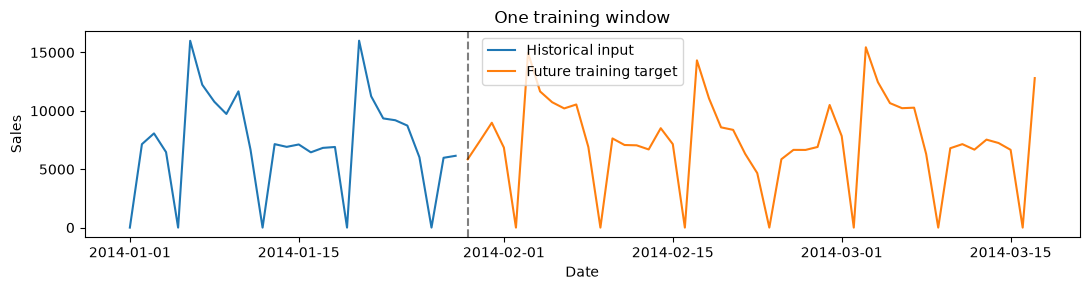

In [5]:
class SalesWindowDataset(Dataset):
    def __init__(self, frame, lookback, horizon, stride):
        self.lookback, self.horizon = lookback, horizon
        self.series, self.windows = {}, []
        self.skipped_windows = 0
        for store, group in frame.groupby("Store", sort=True):
            group = group.sort_values("Date")
            features = encode_features(group)
            target = encode_sales(group["Sales"])
            history = np.column_stack([target, features]).astype(np.float32)
            dates = group["Date"].to_numpy(dtype="datetime64[D]")
            store_id = store_to_index[int(store)]
            self.series[store_id] = (history, features, target, dates)
            last_start = len(group) - horizon
            starts = list(range(lookback, last_start + 1, stride))
            if last_start >= lookback and last_start not in starts:
                starts.append(last_start)
            for start in starts:
                dates_in_window = dates[start - lookback:start + horizon]
                if np.all(np.diff(dates_in_window) == np.timedelta64(1, "D")):
                    self.windows.append((store_id, start))
                else:
                    self.skipped_windows += 1
        if not self.windows:
            raise ValueError("No complete training windows. Use more history or a shorter LOOKBACK.")

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):
        store_id, start = self.windows[index]
        history, features, target, _ = self.series[store_id]
        return (
            torch.from_numpy(history[start - self.lookback:start]),
            torch.from_numpy(features[start:start + self.horizon]),
            torch.tensor(store_id, dtype=torch.long),
            torch.from_numpy(target[start:start + self.horizon]),
        )

train_dataset = SalesWindowDataset(train_df, LOOKBACK, HORIZON, TRAIN_STRIDE)
if SMOKE_TEST and len(train_dataset.windows) > 200:
    indices = np.random.default_rng(SEED).choice(len(train_dataset), 200, replace=False)
    train_dataset.windows = [train_dataset.windows[i] for i in sorted(indices)]

def make_train_loader():
    return DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(SEED),
    )

example_history, example_future, example_store, example_target = train_dataset[0]
print("Training windows:", len(train_dataset))
print("Skipped windows crossing missing dates:", train_dataset.skipped_windows)
print("One history:", tuple(example_history.shape))
print("One future feature block:", tuple(example_future.shape))
print("One target block:", tuple(example_target.shape))

store_id, start = train_dataset.windows[0]
history, _, target, dates = train_dataset.series[store_id]
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(dates[start - LOOKBACK:start], np.expm1(history[start - LOOKBACK:start, 0] * sales_std + sales_mean),
        label="Historical input")
ax.plot(dates[start:start + HORIZON], np.expm1(target[start:start + HORIZON] * sales_std + sales_mean),
        label="Future training target")
ax.axvline(dates[start], color="black", linestyle="--", alpha=0.5)
ax.set(title="One training window", xlabel="Date", ylabel="Sales")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Build the Validation Forecast

Every validation store uses the last 28 observed days **before** the validation start. We predict the entire validation period in one call. The function below rejects future frames containing Sales or Customers, making the information boundary explicit.

Validation may be shorter than the training horizon. The shared daily head supports any forecast length up to H; lead times always use the same H denominator.

In [6]:
def make_forecast_inputs(history_frame, future_frame):
    forbidden = {"Sales", "Customers"} & set(future_frame.columns)
    if forbidden:
        raise ValueError(f"Future features must exclude: {sorted(forbidden)}")
    history_groups = {
        int(store): group.sort_values("Date")
        for store, group in history_frame.groupby("Store")
    }
    histories, futures, store_ids, rows = [], [], [], []
    common_dates = pd.date_range(future_frame["Date"].min(), future_frame["Date"].max(), freq="D")
    if not 1 <= len(common_dates) <= HORIZON:
        raise ValueError("Future date span must be between 1 and HORIZON days.")
    for store, group in future_frame.groupby("Store", sort=True):
        group = group.sort_values("Date")
        assert np.array_equal(group["Date"].to_numpy(), common_dates.to_numpy())
        origin = common_dates[0]
        past = history_groups[int(store)]
        past = past[past["Date"] < origin].tail(LOOKBACK)
        expected_past = pd.date_range(origin - pd.Timedelta(days=LOOKBACK), periods=LOOKBACK)
        assert np.array_equal(past["Date"].to_numpy(), expected_past.to_numpy()), (
            f"Store {store} does not have {LOOKBACK} consecutive historical days."
        )
        histories.append(np.column_stack([encode_sales(past["Sales"]), encode_features(past)]))
        futures.append(encode_features(group))
        store_ids.append(store_to_index[int(store)])
        rows.append(group)
    tensors = (
        torch.tensor(np.stack(histories), dtype=torch.float32),
        torch.tensor(np.stack(futures), dtype=torch.float32),
        torch.tensor(store_ids, dtype=torch.long),
    )
    forecast_rows = pd.concat(rows, ignore_index=True)
    return tensors, forecast_rows

val_inputs, val_rows = make_forecast_inputs(train_df, val_df.drop(columns="Sales"))
val_labels = val_rows[["Store", "Date"]].merge(
    val_df[["Store", "Date", "Sales"]], on=["Store", "Date"],
    how="left", validate="one_to_one", sort=False
)["Sales"].to_numpy()
assert np.isfinite(val_labels).all()
print("Validation input shapes:", [tuple(tensor.shape) for tensor in val_inputs])
print("Last historical date:", val_dates[0] - pd.Timedelta(days=1))
print("First forecast date:", val_dates[0])

Validation input shapes: [(50, 28, 29), (50, 42, 28), (50,)]
Last historical date: 2015-06-19 00:00:00
First forecast date: 2015-06-20 00:00:00


## 7. Define Vanilla RNN, LSTM and GRU

| Model | Memory mechanism | What the experiment investigates |
|---|---|---|
| Vanilla RNN | One hidden state updated with tanh | Whether a simple recurrent summary is sufficient. |
| LSTM | Hidden state and cell state, controlled by gates | Whether more flexible memory helps retain useful history. |
| GRU | Hidden state with update and reset gates | Whether a smaller gated design gives a useful accuracy/time tradeoff. |

As in the reference, inputs use **batch_first=True** and the last hidden state feeds a regression head. LSTM returns **(hidden, cell)**; we take **hidden** for the head.

Only the recurrent layer changes between runs. All models use PyTorch's default initialization, the same head, one shared store embedding, and the same training settings. Equal hidden sizes do **not** imply equal parameter counts, so we report those counts too.

In [7]:
class RecurrentSalesModel(nn.Module):
    def __init__(self, model_type):
        super().__init__()
        recurrent_class = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[model_type]
        self.recurrent = recurrent_class(
            input_size=len(encoded_feature_names) + 1,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT if NUM_LAYERS > 1 else 0.0,
        )
        self.store_embedding = nn.Embedding(len(selected_stores), STORE_EMBEDDING_SIZE)
        self.head = nn.Sequential(
            nn.Linear(HIDDEN_SIZE + STORE_EMBEDDING_SIZE + len(encoded_feature_names) + 1, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, 1),
        )

    def forward(self, history, future_features, store_ids):
        _, hidden = self.recurrent(history)
        if isinstance(hidden, tuple):
            hidden = hidden[0]
        context = torch.cat([hidden[-1], self.store_embedding(store_ids)], dim=1)
        batch_size, steps, _ = future_features.shape
        context = context.unsqueeze(1).expand(-1, steps, -1)
        lead = torch.arange(1, steps + 1, device=history.device, dtype=history.dtype) / HORIZON
        lead = lead.view(1, steps, 1).expand(batch_size, -1, -1)
        combined = torch.cat([context, future_features, lead], dim=-1)
        return self.head(combined).squeeze(-1)

parameter_counts = {}
for model_type in MODEL_TYPES:
    seed_everything(SEED)
    model = RecurrentSalesModel(model_type).to(device)
    parameter_counts[model_type] = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model.eval()
    with torch.no_grad():
        output = model(*(tensor[:2].to(device) for tensor in val_inputs))
    assert output.shape == (min(2, len(selected_stores)), len(val_dates))
    print(f"{model_type}: {parameter_counts[model_type]:,} parameters; output {tuple(output.shape)}")
del model

RNN: 6,961 parameters; output (2, 42)
LSTM: 13,009 parameters; output (2, 42)


GRU: 10,993 parameters; output (2, 42)


## 8. Metrics and Training Helpers

We train with MSE on standardized log-sales. This is a constant rescaling of MSE on log-sales, which reduces the influence of very large absolute sales values compared with raw-sales MSE.

For evaluation we convert predictions back to sales, clip negative predictions to zero, and set known closed-store days to zero.

- **RMSPE:** root mean squared percentage error, evaluated where actual Sales > 0. Lower is better; 0.20 corresponds to 20% root mean squared relative error.
- **MAE:** average absolute error in sales units, including zero-sales days.
- **RMSE:** square root of average squared error in sales units, including zero-sales days.

These are distinct objectives: minimizing log-MSE does not guarantee the best RMSPE. We select each checkpoint and stop early using validation RMSPE. Validation therefore guides model selection; it is not an untouched final test.

Gradients are clipped to norm 1, following the stabilization idea used for the reference's Vanilla RNN.

In [8]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=np.float64)
    predicted = np.asarray(predicted, dtype=np.float64)
    assert actual.shape == predicted.shape and len(actual) > 0
    assert np.isfinite(actual).all() and np.isfinite(predicted).all()
    positive = actual > 0
    return {
        "RMSPE": float(np.sqrt(np.mean(((actual[positive] - predicted[positive]) / actual[positive]) ** 2)))
                 if positive.any() else np.nan,
        "MAE": float(np.mean(np.abs(actual - predicted))),
        "RMSE": float(np.sqrt(np.mean((actual - predicted) ** 2))),
    }

def predict_scaled(model, inputs):
    model.eval()
    outputs = []
    with torch.inference_mode():
        for start in range(0, len(inputs[0]), BATCH_SIZE):
            batch = [tensor[start:start + BATCH_SIZE].to(device) for tensor in inputs]
            outputs.append(model(*batch).cpu().numpy())
    return np.concatenate(outputs, axis=0)

def fit_model(model_type):
    seed_everything(SEED)
    model = RecurrentSalesModel(model_type).to(device)
    loader = make_train_loader()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    criterion = nn.MSELoss()
    history = []
    best_score, best_epoch, stale_epochs = float("inf"), 0, 0
    checkpoint_path = RUN_DIR / f"{model_type.lower()}_best.pt"
    started = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        loss_sum, examples = 0.0, 0
        for past, future, stores, target in loader:
            past, future, stores, target = [
                tensor.to(device) for tensor in (past, future, stores, target)
            ]
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(past, future, stores), target)
            if not torch.isfinite(loss):
                raise RuntimeError(f"{model_type} training loss is not finite.")
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            loss_sum += float(loss.item()) * len(past)
            examples += len(past)

        val_scaled = predict_scaled(model, val_inputs).ravel()
        predictions = decode_sales(val_scaled, val_rows["Open"].to_numpy())
        scores = regression_metrics(val_labels, predictions)
        val_mse = float(np.mean((val_scaled - encode_sales(val_labels)) ** 2))
        history.append({
            "epoch": epoch, "train_mse_scaled_log": loss_sum / examples,
            "validation_mse_scaled_log": val_mse, **scores,
        })
        print(f"{model_type:4s} | epoch {epoch:02d} | loss {loss_sum / examples:.4f} | "
              f"validation RMSPE {scores['RMSPE']:.4f} | MAE {scores['MAE']:.1f}")

        if not np.isfinite(scores["RMSPE"]):
            raise ValueError("Validation needs at least one positive-sales observation.")
        if scores["RMSPE"] < best_score:
            best_score, best_epoch, stale_epochs = scores["RMSPE"], epoch, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            stale_epochs += 1
            if stale_epochs >= PATIENCE:
                print(f"Early stopping; best epoch: {best_epoch}.")
                break

    training_seconds = time.perf_counter() - started
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    predictions = decode_sales(
        predict_scaled(model, val_inputs).ravel(), val_rows["Open"].to_numpy()
    )
    record = {
        "model": model_type, **regression_metrics(val_labels, predictions),
        "parameters": parameter_counts[model_type], "best_epoch": best_epoch,
        "epochs_run": len(history), "training_seconds": training_seconds,
        "comparison_scope": "Same training stores, history, and validation rows",
    }
    history_frame = pd.DataFrame(history)
    history_frame.to_csv(RUN_DIR / f"{model_type.lower()}_history.csv", index=False)
    return model, history_frame, predictions, record

## 9. Train All Three Models

Each run resets the random seed and training-window shuffle order. Hidden size and maximum epochs are shared, while early stopping may result in different numbers of epochs. The checkpoint with the lowest validation RMSPE is restored before evaluation.

In [9]:
models, histories, validation_predictions, records = {}, {}, {}, []
for model_type in MODEL_TYPES:
    trained_model, history_frame, predictions, record = fit_model(model_type)
    models[model_type] = trained_model.cpu()
    histories[model_type] = history_frame
    validation_predictions[model_type] = predictions
    records.append(record)

recurrent_results = pd.DataFrame(records).sort_values("RMSPE").reset_index(drop=True)
best_model_name = recurrent_results.loc[0, "model"]
display(recurrent_results)
print("Best recurrent model on this validation split:", best_model_name)

RNN  | epoch 01 | loss 0.6107 | validation RMSPE 0.7109 | MAE 3628.2


RNN  | epoch 02 | loss 0.1522 | validation RMSPE 0.5451 | MAE 2525.4


RNN  | epoch 03 | loss 0.0503 | validation RMSPE 0.3347 | MAE 1518.9


RNN  | epoch 04 | loss 0.0302 | validation RMSPE 0.3906 | MAE 1591.4


RNN  | epoch 05 | loss 0.0228 | validation RMSPE 0.3316 | MAE 1388.4


...

GRU  | epoch 13 | loss 0.0095 | validation RMSPE 0.2595 | MAE 1108.2


GRU  | epoch 14 | loss 0.0093 | validation RMSPE 0.2896 | MAE 1254.1


GRU  | epoch 15 | loss 0.0092 | validation RMSPE 0.2964 | MAE 1302.8
Early stopping; best epoch: 11.


,model,RMSPE,MAE,RMSE,parameters,best_epoch,epochs_run,training_seconds,comparison_scope
0,LSTM,0.232608,923.451542,1368.715474,13009,13,15,5.480706,"Same training stores, history, and validation ..."
1,GRU,0.257160,1107.467346,1611.510808,10993,11,15,8.167549,"Same training stores, history, and validation ..."
2,RNN,0.267280,1198.976118,2007.731909,6961,6,10,3.719614,"Same training stores, history, and validation ..."


Best recurrent model on this validation split: LSTM


## 10. Compare With Baselines and Notebook 03

Two inexpensive baselines are recomputed using this notebook's training data and exact validation rows:

- **Store + weekday mean:** mean historical sales for the same store and weekday.
- **Repeat last week:** repeat the store's final observed seven days throughout the forecast period.

Both enforce zero sales on known closed days. The weekly baseline only repeats days observed before validation; it never reads an earlier validation target.

When Notebook 03's saved predictions cover the same store-date pairs and contain matching actual sales, we also display its score on these rows. It is an **external comparison**: Notebook 03 may have used more stores, more history, and different features. It cannot isolate the effect of recurrent architecture.

,model,RMSPE,MAE,RMSE,comparison_scope
0,Notebook 03 MLP,0.131980,598.209406,964.096570,External: training data/settings may differ
1,LSTM,0.232608,923.451542,1368.715474,"Same training stores, history, and validation ..."
2,Store + weekday mean,0.234034,1108.748613,1606.526356,"Same training stores, history, and validation ..."
3,GRU,0.257160,1107.467346,1611.510808,"Same training stores, history, and validation ..."
4,RNN,0.267280,1198.976118,2007.731909,"Same training stores, history, and validation ..."
5,Repeat last week,0.391585,1391.429524,2146.827196,"Same training stores, history, and validation ..."


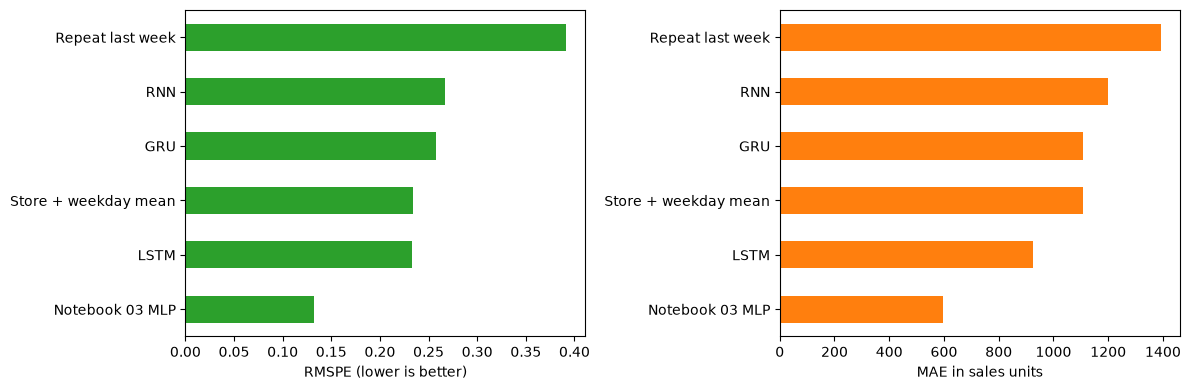

In [10]:
baseline_train = train_df[["Store", "Date", "Sales"]].copy()
baseline_train["weekday"] = baseline_train["Date"].dt.dayofweek
weekday_means = baseline_train.groupby(["Store", "weekday"])["Sales"].mean()
store_means = baseline_train.groupby("Store")["Sales"].mean()
global_mean = baseline_train["Sales"].mean()

keys = pd.MultiIndex.from_arrays([
    val_rows["Store"], val_rows["Date"].dt.dayofweek
], names=["Store", "weekday"])
mean_predictions = weekday_means.reindex(keys).to_numpy()
fallback = val_rows["Store"].map(store_means).fillna(global_mean).to_numpy()
mean_predictions = np.where(np.isnan(mean_predictions), fallback, mean_predictions)
mean_predictions = np.where(val_rows["Open"].to_numpy() == 0, 0, mean_predictions)

last_week_start = val_dates[0] - pd.Timedelta(days=7)
repeat_dates = last_week_start + pd.to_timedelta(
    (val_rows["Date"] - val_dates[0]).dt.days.to_numpy() % 7, unit="D"
)
sales_lookup = train_df.set_index(["Store", "Date"])["Sales"]
repeat_keys = pd.MultiIndex.from_arrays([val_rows["Store"], repeat_dates])
weekly_predictions = sales_lookup.reindex(repeat_keys).to_numpy()
assert np.isfinite(weekly_predictions).all()
weekly_predictions = np.where(val_rows["Open"].to_numpy() == 0, 0, weekly_predictions)

comparison_records = records.copy()
for name, predicted in [
    ("Store + weekday mean", mean_predictions), ("Repeat last week", weekly_predictions)
]:
    validation_predictions[name] = predicted
    comparison_records.append({
        "model": name, **regression_metrics(val_labels, predicted),
        "comparison_scope": "Same training stores, history, and validation rows",
    })

nn03_path = PROJECT_DIR / "outputs" / "predictions" / "validation_predictions_pytorch_nn.csv"
if nn03_path.exists():
    nn03 = pd.read_csv(nn03_path, parse_dates=["Date"])
    required = {"Store", "Date", "Sales", "prediction"}
    if required.issubset(nn03.columns) and not nn03.duplicated(["Store", "Date"]).any():
        matched = val_rows[["Store", "Date"]].merge(
            nn03[["Store", "Date", "Sales", "prediction"]],
            on=["Store", "Date"], how="left", validate="one_to_one", sort=False
        )
        if (matched[["Sales", "prediction"]].notna().all().all()
                and np.isfinite(matched["prediction"]).all()
                and np.allclose(matched["Sales"], val_labels)):
            predicted = matched["prediction"].to_numpy()
            validation_predictions["Notebook 03 MLP"] = predicted
            comparison_records.append({
                "model": "Notebook 03 MLP", **regression_metrics(val_labels, predicted),
                "comparison_scope": "External: training data/settings may differ",
            })
        else:
            print("Notebook 03 comparison skipped: missing predictions or mismatched actual sales.")
    else:
        print("Notebook 03 comparison skipped: incompatible columns or duplicate rows.")
else:
    print("Notebook 03 predictions are absent; both baselines are still available.")

comparison_df = pd.DataFrame(comparison_records).sort_values("RMSPE").reset_index(drop=True)
display(comparison_df[["model", "RMSPE", "MAE", "RMSE", "comparison_scope"]])
comparison_df.to_csv(RUN_DIR / "model_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison_df.plot.barh(x="model", y="RMSPE", ax=axes[0], legend=False, color="tab:green")
comparison_df.plot.barh(x="model", y="MAE", ax=axes[1], legend=False, color="tab:orange")
axes[0].set(xlabel="RMSPE (lower is better)", ylabel="")
axes[1].set(xlabel="MAE in sales units", ylabel="")
fig.tight_layout()
fig.savefig(RUN_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Learning Curves

The left plots compare training and validation MSE on standardized log-sales, before the closed-day prediction rule. The right plots show validation RMSPE after converting back to sales and applying that rule.

A decreasing training loss with worsening validation error is evidence of overfitting on this split. Lower loss alone does not establish a better sales forecast.

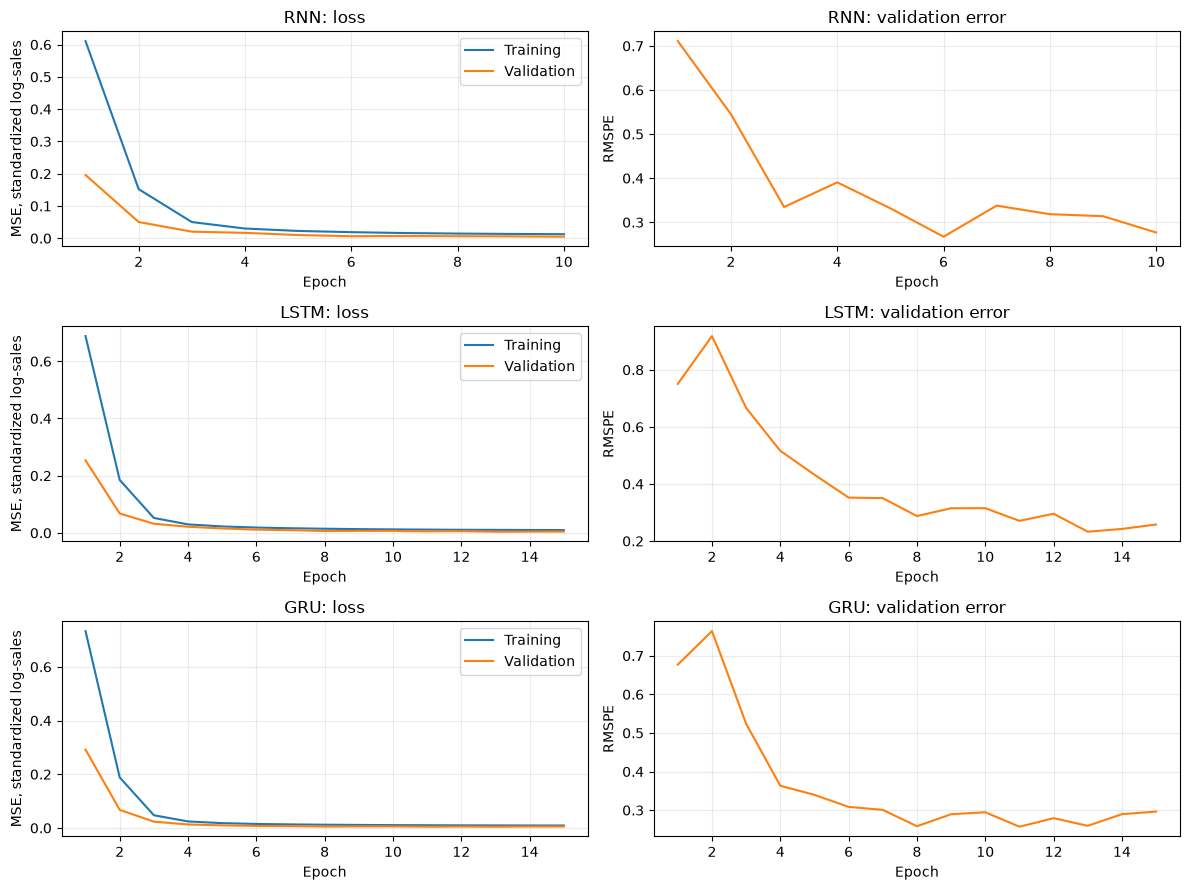

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for row, name in enumerate(MODEL_TYPES):
    hist = histories[name]
    axes[row, 0].plot(hist["epoch"], hist["train_mse_scaled_log"], label="Training")
    axes[row, 0].plot(hist["epoch"], hist["validation_mse_scaled_log"], label="Validation")
    axes[row, 0].set(title=f"{name}: loss", xlabel="Epoch", ylabel="MSE, standardized log-sales")
    axes[row, 0].legend()
    axes[row, 1].plot(hist["epoch"], hist["RMSPE"], color="tab:orange")
    axes[row, 1].set(title=f"{name}: validation error", xlabel="Epoch", ylabel="RMSPE")
    for ax in axes[row]:
        ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RUN_DIR / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Weekly and Monthly Forecast Visualizations

To keep plots readable, we aggregate sales into weekly and monthly means, following Notebook 01. These are **mean daily sales across the selected store-date rows**, not total weekly or monthly revenue. Boundary weeks and months may be partial.

The accuracy scores above are still calculated on individual store-day predictions. Aggregated plots can hide errors that cancel across stores.

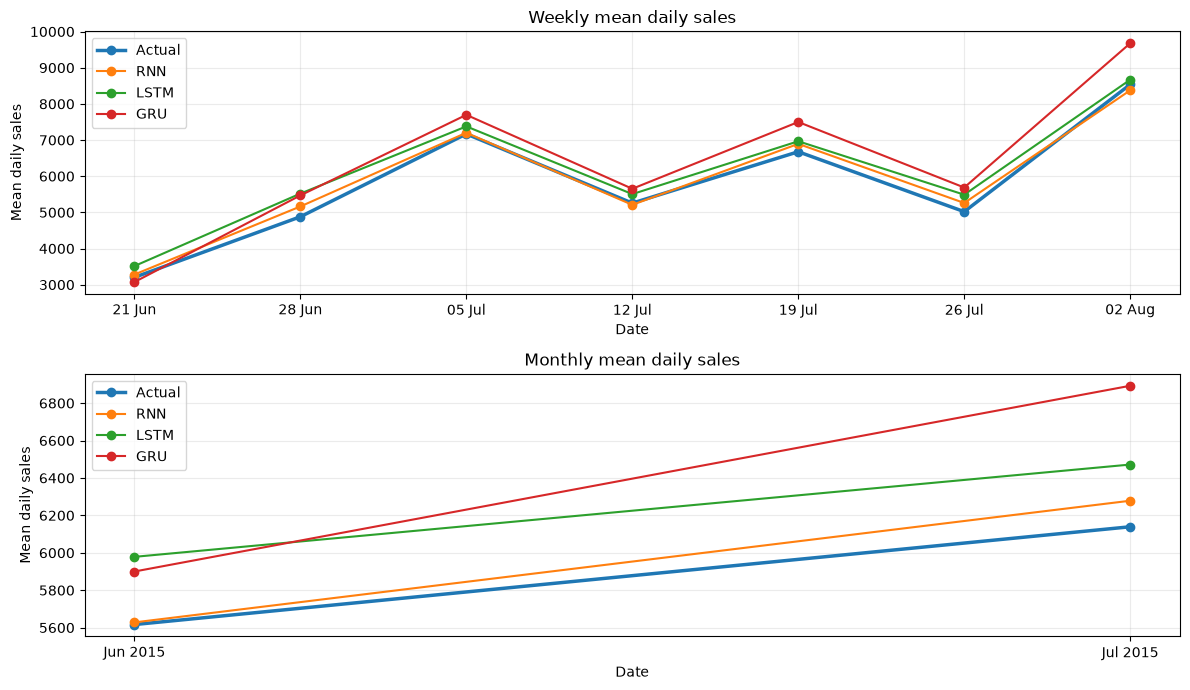

In [12]:
validation_frame = val_rows[["Store", "Date", "Open", "Promo"]].copy()
validation_frame["Sales"] = val_labels
for name, predictions in validation_predictions.items():
    validation_frame[name] = predictions
plot_columns = ["Sales"] + list(MODEL_TYPES)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, frequency, title in zip(
    axes, ["W-SUN", "MS"], ["Weekly mean daily sales", "Monthly mean daily sales"]
):
    grouped = validation_frame.set_index("Date")[plot_columns].resample(frequency).mean()
    for name in plot_columns:
        ax.plot(grouped.index, grouped[name], marker="o", label="Actual" if name == "Sales" else name,
                linewidth=2.5 if name == "Sales" else 1.5)
    ax.set_xticks(grouped.index)
    ax.set_xticklabels(grouped.index.strftime("%b %Y" if frequency == "MS" else "%d %b"))
    ax.set(title=title, xlabel="Date", ylabel="Mean daily sales")
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
fig.savefig(RUN_DIR / "weekly_monthly_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Error by Forecast Week and Promotion

We check whether forecasts deteriorate farther into the future and whether promotion days are harder to predict. A forecast week means days 1-7, 8-14, and so on after the forecast origin; it is distinct from a calendar week.

These summaries describe this validation period. They do not establish that promotions cause an error difference.

,dimension,value,model,rows,positive_sales_rows,RMSPE,MAE,RMSE
18,Promo,0,RNN,1350,1057,0.285751,967.820919,1760.807034
19,Promo,0,LSTM,1350,1057,0.266292,811.705664,1253.864763
20,Promo,0,GRU,1350,1057,0.263662,878.800303,1353.758924
21,Promo,1,RNN,750,750,0.238834,1615.055476,2388.717279
22,Promo,1,LSTM,750,750,0.174420,1124.594121,1554.204433
23,Promo,1,GRU,750,750,0.247707,1519.068023,1993.166835


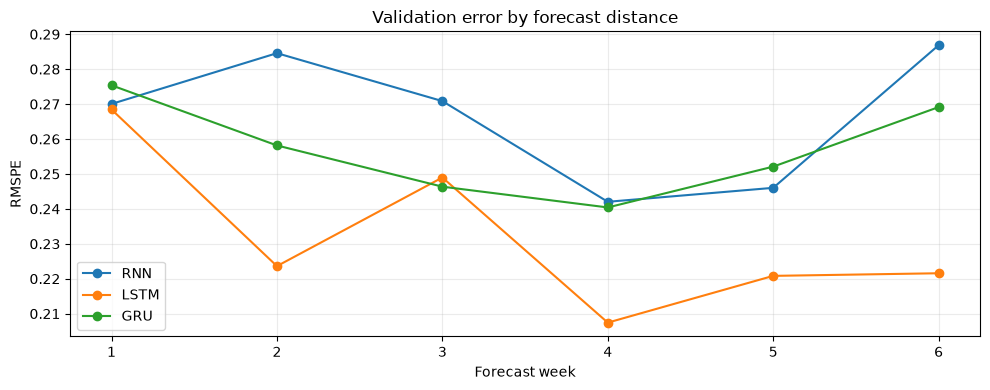

In [13]:
validation_frame["forecast_day"] = (validation_frame["Date"] - val_dates[0]).dt.days + 1
validation_frame["forecast_week"] = (validation_frame["forecast_day"] - 1) // 7 + 1
domain_records = []
for dimension in ["forecast_week", "Promo"]:
    for value, group in validation_frame.groupby(dimension):
        for name in MODEL_TYPES:
            domain_records.append({
                "dimension": dimension, "value": int(value), "model": name,
                "rows": len(group), "positive_sales_rows": int(group["Sales"].gt(0).sum()),
                **regression_metrics(group["Sales"].to_numpy(), group[name].to_numpy()),
            })
domain_results = pd.DataFrame(domain_records)
display(domain_results[domain_results["dimension"] == "Promo"])
weekly_errors = domain_results[domain_results["dimension"] == "forecast_week"]
fig, ax = plt.subplots(figsize=(10, 4))
for name in MODEL_TYPES:
    group = weekly_errors[weekly_errors["model"] == name]
    ax.plot(group["value"], group["RMSPE"], marker="o", label=name)
ax.set(xlabel="Forecast week", ylabel="RMSPE", title="Validation error by forecast distance")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RUN_DIR / "error_by_forecast_week.png", dpi=150, bbox_inches="tight")
plt.show()
domain_results.to_csv(RUN_DIR / "domain_analysis.csv", index=False)
validation_frame.to_csv(RUN_DIR / "validation_predictions.csv", index=False)

## 14. Forecast the Test Period

After selecting models, validation sales are historical observations available before the test starts. We may therefore include them in the test input history. The models and preprocessing remain fitted on the original training set; this notebook does not retrain them on validation labels.

We save predictions for all three architectures, preserving the test Id when present. With the default store sample these files cover **only the selected stores**. A file named submission is saved only when every row of the prepared test is covered and its Id is unique. If Notebook 01 itself sampled its test data, also check coverage against the original test.csv before submitting externally.

In [14]:
observed_history = pd.concat([train_df, val_df], ignore_index=True).sort_values(["Store", "Date"])
test_inputs, test_rows = make_forecast_inputs(observed_history, test_df)
test_output_paths = {}

for name in MODEL_TYPES:
    model = models[name].to(device)
    predictions = decode_sales(
        predict_scaled(model, test_inputs).ravel(), test_rows["Open"].to_numpy()
    )
    id_columns = (["Id"] if "Id" in test_rows.columns else []) + ["Store", "Date"]
    output = test_rows[id_columns].copy()
    output["Sales"] = predictions
    output = output.sort_values("Id" if "Id" in output.columns else ["Store", "Date"])
    assert len(output) == len(test_df)
    assert not output.duplicated(["Store", "Date"]).any()
    output_path = RUN_DIR / f"test_predictions_{name.lower()}.csv"
    output.to_csv(output_path, index=False)
    test_output_paths[name] = str(output_path.relative_to(PROJECT_DIR))
    models[name] = model.cpu()

    if (len(output) == full_prepared_test_rows and "Id" in output.columns
            and output["Id"].notna().all() and output["Id"].is_unique):
        output[["Id", "Sales"]].to_csv(RUN_DIR / f"submission_{name.lower()}.csv", index=False)

print(f"Saved forecasts for {len(test_df):,} / {full_prepared_test_rows:,} prepared test rows.")
print("Selected recurrent model:", best_model_name)
display(pd.read_csv(PROJECT_DIR / test_output_paths[best_model_name]).head())

Saved forecasts for 2,400 / 41,088 prepared test rows.
Selected recurrent model: LSTM


,Id,Store,Date,Sales
0,54,71,2015-09-17,11616.025943
1,58,75,2015-09-17,7551.652805
2,70,91,2015-09-17,5518.974916
3,73,94,2015-09-17,8447.161550
4,77,101,2015-09-17,8859.000614


## 15. Save the Experiment

The run directory contains the three best checkpoints, preprocessing metadata, training histories, comparison scores, validation/test predictions, and plots. Smoke-test results use a separate directory.

The checkpoints require the model class and saved preprocessing settings to be reconstructed. Store order, category order, scaling values, horizon, and architecture sizes are therefore included in the metadata.

In [15]:
metadata = {
    "reference_notebook": "Recurrent Torch.ipynb",
    "task": "Direct multi-step store-sales regression using recurrent history encoders",
    "best_recurrent_model": best_model_name,
    "selection_metric": "Validation RMSPE on positive actual sales",
    "smoke_test": SMOKE_TEST,
    "selected_stores": [int(store) for store in selected_stores],
    "store_to_index": {str(store): index for store, index in store_to_index.items()},
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "encoded_feature_names": encoded_feature_names,
    "category_levels": category_levels,
    "numeric_means": numeric_means.to_dict(),
    "numeric_stds": numeric_stds.to_dict(),
    "sales_transform": {"name": "standardized log1p", "mean": sales_mean, "std": sales_std},
    "settings": {
        "seed": SEED, "max_stores": MAX_STORES, "history_start": HISTORY_START,
        "lookback": LOOKBACK, "horizon": HORIZON, "train_stride": TRAIN_STRIDE,
        "batch_size": BATCH_SIZE, "max_epochs": EPOCHS, "patience": PATIENCE,
        "hidden_size": HIDDEN_SIZE, "store_embedding_size": STORE_EMBEDDING_SIZE,
        "num_layers": NUM_LAYERS, "dropout": DROPOUT,
        "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
        "gradient_clip_norm": 1.0,
    },
    "date_ranges": {
        name: [str(frame["Date"].min().date()), str(frame["Date"].max().date())]
        for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]
    },
    "coverage": {
        "training_windows": len(train_dataset), "validation_rows": len(val_df),
        "test_prediction_rows": len(test_df), "prepared_test_rows": full_prepared_test_rows,
    },
    "recurrent_results": records,
    "checkpoint_files": {name: f"{name.lower()}_best.pt" for name in MODEL_TYPES},
    "test_prediction_files": test_output_paths,
    "versions": {
        "python": platform.python_version(), "torch": str(torch.__version__),
        "numpy": np.__version__, "pandas": pd.__version__,
    },
}
with open(RUN_DIR / "experiment_metadata.json", "w", encoding="utf-8") as handle:
    json.dump(metadata, handle, indent=2, allow_nan=False)

print("Artifacts saved to:", RUN_DIR.resolve())
print("Models:", ", ".join(MODEL_TYPES))
print("Best recurrent validation RMSPE:", round(float(recurrent_results.iloc[0]["RMSPE"]), 4))

Artifacts saved to: C:\Users\Palum\OneDrive\Desktop\Dottorato IA\(IML) Introduction to Machine Learning\Project2\THEBESTONETHEREIS\outputs\recurrent_notebook\school_run
Models: RNN, LSTM, GRU
Best recurrent validation RMSPE: 0.2326


## 16. Discussion for the School Report

Use the actual outputs to answer these questions:

1. Which recurrent model has the lowest validation RMSPE? Does it also win on MAE and RMSE?
2. Does any recurrent model beat the two baselines on the same rows?
3. Is the accuracy gain worth the additional training time and parameter count?
4. Do the learning curves suggest overfitting? Does error increase with forecast distance?
5. Are errors larger on promotion days? Do weekly and monthly plots conceal daily mistakes?
6. How does the result compare with Notebook 03, accounting for different training data and feature choices?

The architecture comparison is the main experiment in this notebook. Useful extensions are to compare 7, 28, and 56 history days; remove historical Sales and retrain to test its contribution; or repeat runs with several seeds. Change one factor at a time and save runs in different directories.

A single sampled set of stores and one chronological validation period do not establish a universal winner. A stronger study would repeat the comparison at several earlier forecast origins, keeping every target after its input history, then evaluate the chosen setup on a final untouched labeled period. The supplied unlabeled test set cannot serve that purpose.